# GMM style clusters

The competitive axis (Glicko-2) tells us how good a fighter is; this notebook builds the style layer that tells us how they fight.

This notebook:

*   Aggregates the Group B features per fighter from the round data
*   Applies recency weighting so a fighter's recent style counts more
*   Fits a Gaussian Mixture Model across k = 3 to 8 and chooses the cluster count on interpretability, with BIC and silhouette as guides
*   Labels the resulting clusters against recognisable archetypes (volume wrestler, knockout striker, distance striker, submission grappler)

Soft assignments throughout; fighters get a probability across cluster types, not a single label, because almost no one in MMA is one pure thing.

Inputs come from `fight_stats_numeric.parquet` (round-level) and `glicko_current_continuous.parquet` (for the eventual axis overlay). Outputs land in the same `Code Outputs` directory as the rest of the pipeline.

## Section 1: Setup

Mount Drive and import the libraries used throughout.

In [ ]:
# BLOCK 1: Drive mount and library imports

from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score

# data location (portable across Drive and a local repo checkout)
try:
    from google.colab import drive
    drive.mount('/content/drive')
except (ImportError, ModuleNotFoundError):
    pass  # not in Colab

DRIVE_DIR = Path('/content/drive/MyDrive/Masters in Artificial Intelligence Applied to Sport/'
                 'Masters Final Project/Pugnator mapper valorem/EDA/Code Outputs')
OUTPUT_DIR = DRIVE_DIR if DRIVE_DIR.exists() else Path('./data')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'Using data directory: {OUTPUT_DIR}')


Mounted at /content/drive


In [ ]:
# BLOCK 2: check for finish and time data

df_pairs = pd.read_parquet(OUTPUT_DIR / 'bout_pairs.parquet')
print(df_pairs.columns.tolist())
print()

# pull out any time related columns
time_cols = [c for c in df_pairs.columns if any(s in c.lower() for s in ['time', 'round', 'finish', 'duration'])]
print(f'time-related columns: {time_cols}')
if time_cols:
    print(df_pairs[time_cols].head(3).to_string())

['FIGHT_ID', 'FIGHTER_W', 'OPPONENT_W', 'RESULT_W', 'SCORE_W', 'METHOD_W', 'METHOD_CAT_W', 'IS_DQ_W', 'EVENT_x_W', 'WEIGHTCLASS_W', 'IS_TITLE_W', 'DIVISION_VALID_W', 'DATE_PARSED_W', 'ERA_W', 'WEIGHTCLASS_CANONICAL_W', 'EVENT_y_W', 'BOUT_W', 'SIG.STR._landed_W', 'SIG.STR._attempted_W', 'TD_landed_W', 'CTRL_secs_W', 'KD_num_W', 'SUB.ATT_num_W', 'LAST_ROUND_W', 'FIGHTER_L', 'OPPONENT_L', 'RESULT_L', 'SCORE_L', 'METHOD_L', 'METHOD_CAT_L', 'IS_DQ_L', 'EVENT_x_L', 'WEIGHTCLASS_L', 'IS_TITLE_L', 'DIVISION_VALID_L', 'DATE_PARSED_L', 'ERA_L', 'WEIGHTCLASS_CANONICAL_L', 'EVENT_y_L', 'BOUT_L', 'SIG.STR._landed_L', 'SIG.STR._attempted_L', 'TD_landed_L', 'CTRL_secs_L', 'KD_num_L', 'SUB.ATT_num_L', 'LAST_ROUND_L', 'strike_diff', 'control_diff', 'kd_diff', 'finish_round', 'method_cat', 'method', 'weightclass', 'era', 'date']

time-related columns: ['LAST_ROUND_W', 'LAST_ROUND_L', 'finish_round']
   LAST_ROUND_W  LAST_ROUND_L  finish_round
0           1.0           1.0           1.0
1           1.0  

## Section 2: Data preparation and integrity

Confirm the finish-time and round data are present, attach finish times to the bout pairs, and check the FIGHT_ID integrity before aggregation.

In [ ]:
# BLOCK 3: add finish times to the bout pairs

# Parse the TIME field ("4:31" > 271s), and joins on (EVENT, BOUT) for
# accurate fight durations.

# output: bout_pairs_enriched.parquet, with total_fight_seconds and
# total_fight_minutes per FIGHT_ID.

GRECO_BASE = 'https://raw.githubusercontent.com/th1555/ufc-fighter-value-mapper/refs/heads/main/raw_data'
df_results = pd.read_csv(f'{GRECO_BASE}/ufc_fight_results.csv')
print(f'loaded fight_results: {len(df_results):,} rows')
print(f'columns: {df_results.columns.tolist()}')
print()

# strip trailing whitespace
df_results['EVENT'] = df_results['EVENT'].str.strip()
df_results['BOUT'] = df_results['BOUT'].str.strip()

# parse the "M:SS" time into seconds
def parse_finish_time(time_str):
    if pd.isna(time_str) or time_str in ('--', '---', ''):
        return None
    try:
        mins, secs = time_str.split(':')
        return int(mins) * 60 + int(secs)
    except (ValueError, AttributeError):
        return None

df_results['finish_time_secs'] = df_results['TIME'].apply(parse_finish_time)
print(f"parsed finish times: {df_results['finish_time_secs'].notna().sum():,} / {len(df_results):,}")
print(f"sample values: {df_results['TIME'].head(5).tolist()}")
print()

df_pairs = pd.read_parquet(OUTPUT_DIR / 'bout_pairs.parquet')
print(f'bout_pairs rows: {len(df_pairs):,}')

# join keys on  bout_pairs
df_pairs_join = df_pairs.copy()
df_pairs_join['_event'] = df_pairs_join['EVENT_y_W'].str.strip()
df_pairs_join['_bout']  = df_pairs_join['BOUT_W'].str.strip()

df_results_slim = df_results[['EVENT', 'BOUT', 'finish_time_secs']].copy()
df_pairs_enriched = df_pairs_join.merge(
    df_results_slim,
    left_on=['_event', '_bout'],
    right_on=['EVENT', 'BOUT'],
    how='left',
    suffixes=('', '_dup')
)

# total duration = full prior rounds (5 min each) + time into the finishing round
df_pairs_enriched['total_fight_seconds'] = (
    (df_pairs_enriched['finish_round'] - 1) * 300 + df_pairs_enriched['finish_time_secs']
)
df_pairs_enriched['total_fight_minutes'] = df_pairs_enriched['total_fight_seconds'] / 60.0

n_total = len(df_pairs_enriched)
n_with_time = df_pairs_enriched['total_fight_seconds'].notna().sum()
print(f'\njoin coverage: {n_with_time:,} / {n_total:,} ({100*n_with_time/n_total:.1f}%)')
print(f'fights missing finish time: {n_total - n_with_time:,}')
print()
print('distribution of total_fight_minutes:')
print(df_pairs_enriched['total_fight_minutes'].describe().round(2).to_string())
print()
print('sample of joined output:')
sample_cols = ['FIGHT_ID', 'finish_round', 'finish_time_secs', 'total_fight_minutes', 'method']
print(df_pairs_enriched[sample_cols].head(5).to_string(index=False))

df_pairs_enriched = df_pairs_enriched.drop(columns=['_event', '_bout', 'EVENT_dup', 'BOUT_dup'], errors='ignore')
df_pairs_enriched.to_parquet(OUTPUT_DIR / 'bout_pairs_enriched.parquet', index=False)
print(f'\nsaved: bout_pairs_enriched.parquet ({len(df_pairs_enriched.columns)} columns)')

loaded fight_results: 8,701 rows
columns: ['EVENT', 'BOUT', 'OUTCOME', 'WEIGHTCLASS', 'METHOD', 'ROUND', 'TIME', 'TIME FORMAT', 'REFEREE', 'DETAILS', 'URL']

parsed finish times: 8,701 / 8,701
sample values: ['5:00', '4:29', '4:08', '5:00', '2:25']

bout_pairs rows: 8,894

join coverage: 8,825 / 8,895 (99.2%)
fights missing finish time: 70

distribution of total_fight_minutes:
count    8825.00
mean       10.40
std         6.11
min         0.08
25%         4.43
50%        12.75
75%        15.00
max        25.00

sample of joined output:
        FIGHT_ID  finish_round  finish_time_secs  total_fight_minutes method
00835554f95fa911           1.0              67.0             1.116667 KO/TKO
00835554f95fa911           1.0              67.0             1.116667 KO/TKO
00835554f95fa911           1.0              67.0             1.116667 KO/TKO
00835554f95fa911           1.0              67.0             1.116667 KO/TKO
00835554f95fa911           1.0             308.0             5.133333 KO/

In [ ]:
# BLOCK 4: check for duplicate FIGHT_IDs

dup_check = df_pairs_enriched.groupby('FIGHT_ID').size().reset_index(name='n')
dup_fights = dup_check[dup_check['n'] > 1]
print(f'duplicated FIGHT_IDs: {len(dup_fights)}')
if len(dup_fights):
    print(dup_fights.to_string(index=False))
    print()
    print('detail on duplicates:')
    print(df_pairs_enriched[df_pairs_enriched['FIGHT_ID'].isin(dup_fights['FIGHT_ID'])][
        ['FIGHT_ID', 'EVENT_y_W', 'BOUT_W', 'finish_round', 'finish_time_secs', 'method']
    ].to_string(index=False))

duplicated FIGHT_IDs: 103
        FIGHT_ID  n
00835554f95fa911 16
040ecf01338dff9e  3
0b71ada6c9209fc9  3
0d872527bbb3cd40  6
1586c14f26880553  2
16f25f0808db6f77  2
17526cb9fb6072ef  4
17ee4caf06981b81  3
18af785da73b5996  2
1c1f8f281b2065e0  4
1f561a3e35a9b48a  4
21aa163b80e504f9  2
2308e0da38efd4ba  3
2963e9a4b8c10bc9  2
323f543eb8abdb36  2
398ff6015a5ba3b5  2
3b020d4914b44fc8  2
3c2c7c095c79a506  3
3cf6583153078f8f  3
3e39aac3e15d75bd  2
3f6c0a76407e1863  2
4165dd0c39926e2f  4
43885ee6cc5ed241  2
43c2c904e1574c59  2
43f6b0c40113d0d8  6
45e49fe8d3d1bfb5  2
4acab67848e78327  2
4b9ae533ccb3fcdf  4
5167a5aec41f8b6d  2
524b49a676498c6d  9
547295977141cbc2  2
56315d5ac11594a5  2
5655639baecd8f6a  8
5d19fa2df1cb61a2  3
62bb4ea8bf86790c  6
6397fba14ce7f674  9
6603f1d60bfeefa9  2
66c029f49d3c5da6  9
6b0430e9c97afec7  2
6ca94b35719eb300  9
7149494344c04258  2
717f3c3932279196  6
72e7d6d5328bc3d6  2
75d16f9eae9c6ea6  2
802c0e4e228996ac  3
8312985b75241b06  3
869d753568a114a6  3
86f566f1425936

In [ ]:
# BLOCK 5: confirm the duplicates dating

df_pairs = pd.read_parquet(OUTPUT_DIR / 'bout_pairs.parquet')
dup_check = df_pairs.groupby('FIGHT_ID').size().reset_index(name='n')
dup_fights = dup_check[dup_check['n'] > 1]
print(f'total fights: {len(df_pairs):,}')
print(f"duplicate FIGHT_IDs: {len(dup_fights)} (covering {dup_fights['n'].sum()} rows)")
print()

# date range of the duplicates vs the dataset overall
dup_dates = df_pairs[df_pairs['FIGHT_ID'].isin(dup_fights['FIGHT_ID'])]['date']
print(f'duplicate date range: {dup_dates.min()} to {dup_dates.max()}')
print()

print('duplicates by year:')
print(pd.to_datetime(dup_dates).dt.year.value_counts().sort_index().to_string())

total fights: 8,894
duplicate FIGHT_IDs: 102 (covering 400 rows)

duplicate date range: 1994-03-11 00:00:00 to 1999-11-19 00:00:00

duplicates by year:
date
1994    119
1995    119
1996     90
1997     52
1998     12
1999      8


## Section 3: Feature aggregation

The Group B style features are aggregated per fighter from the round data, with recency weighting so recent bouts count more. Before aggregation, an era filter restricts the data to the modern UFC.

### Era filter (UFC 28 onward)

A duplicate check on `FIGHT_ID` in `bout_pairs_enriched.parquet` flagged 102 issues over 400 rows. All of them were pre-2000, with the duplicate date range ending sharply on 19 November 1999 (UFC 23, the last tournament based event); UFC 24 onward is clean.

The cause is in the earlier ID construction, not in this notebook's join: early UFC events ran as one night tournaments where a single fighter could fight three or four times on the same card. The `FIGHT_ID` hash collapses those bouts into one ID when it should have kept them separate; a single ID maps to multiple Royce Gracie fights at UFC 2 (against DeLucia, Ichihara, Smith and Pardoel).

Rather than rebuild the IDs and rerun the rating pipeline (as all fighters involved are long inactive), this notebook filters out pre-2000 events at the aggregation step. The argument for the filter is methodological and pragmatic:

- Pre-2000 UFC was a different sport. No weight classes properly enforced, no rounds in the modern sense, no unified rules, and stats are sparsely populated for that era.
- The Group B features are computed against per-minute and per-15-minute denominators that assume the modern round structure.
- The project's framing is the post-PPV US subscription market. Tournament-era fighters were never going to feature on the live dashboard.

Cutoff is UFC 28 (17 November 2000), the first event after the unified rules era began stabilising and the point most analysts use to mark the modern UFC. The four UFC 24 to 27 events (early 2000) are also excluded; they used unified rules in name only.

Rebuilding `FIGHT_ID` for full data integrity is logged as a future-work item rather than blocking work now.

### Group B feature definitions

The eleven Group B features used as input to the GMM are computed from the round-level `fight_stats_numeric.parquet`. All per-time-unit rates use exact total fight minutes derived from the `fight_results` TIME field: `(finish_round - 1) * 5 + finish_minutes_within_round`, summed across a fighter's bouts. See the deviation log (aggregation choices) for why exact durations were used over a scheduled-rounds approximation.

| # | Feature | Computed as | Notes |
|---|---|---|---|
| 1 | Significant strikes landed per minute | `sum(SIG.STR._landed) / total_fight_minutes` | volume signal, distinguishes high-output strikers |
| 2 | Significant strike accuracy | `sum(SIG.STR._landed) / sum(SIG.STR._attempted)` | aggregate ratio across all fights, not the mean of per-round ratios |
| 3 | Significant strikes absorbed per minute | `sum(opponent SIG.STR._landed) / total_fight_minutes` | opponent strikes per round via self-join on `(EVENT, BOUT, ROUND)` |
| 4 | Takedown attempts per 15 minutes | `sum(TD_attempted) / total_fight_minutes * 15` | wrestling engagement signal |
| 5 | Takedown accuracy | `sum(TD_landed) / sum(TD_attempted)` | NaN when no takedown attempts (kept as NaN, not imputed) |
| 6 | Submission attempts per 15 minutes | `sum(SUB.ATT_num) / total_fight_minutes * 15` | grappling threat signal |
| 7 | Control time percentage | `sum(CTRL_secs) / (total_fight_minutes * 60)` | bounded [0, 1] |
| 8 | Knockdown rate per fight | `sum(KD_num) / n_fights` | the only per-fight rather than per-time feature |
| 9 | Distance strike share | `sum(DISTANCE_landed) / sum(SIG.STR._landed)` | range proxy |
| 10 | Clinch strike share | `sum(CLINCH_landed) / sum(SIG.STR._landed)` | kept (no collinearity correction applied) |
| 11 | Ground strike share | `sum(GROUND_landed) / sum(SIG.STR._landed)` | shares 9 to 11 sum to 1.0 by construction |

In [ ]:
# BLOCK 6a: aggregate Group B features per fighter from round data

df_pairs = pd.read_parquet(OUTPUT_DIR / 'bout_pairs_enriched.parquet')

# strip and use from existing data
df_pairs['EVENT'] = df_pairs['EVENT'].str.strip()
df_pairs['BOUT'] = df_pairs['BOUT'].str.strip()

# UFC 28 onward (17 Nov 2000)
ERA_CUTOFF = pd.Timestamp('2000-11-17')
df_pairs_modern = df_pairs[df_pairs['date'] >= ERA_CUTOFF].drop_duplicates(subset='FIGHT_ID')

print(f'bout_pairs total: {len(df_pairs):,}')
print(f'bout_pairs modern era (>= UFC 28): {len(df_pairs_modern):,}')
print(f'dropped: {len(df_pairs) - len(df_pairs_modern):,} pre-2000 and duplicate rows')

# one row per (EVENT, BOUT) for duration lookup
bout_duration = df_pairs_modern[
    ['EVENT', 'BOUT', 'total_fight_minutes']
].drop_duplicates(subset=['EVENT', 'BOUT'])
print(f'bout duration lookup: {len(bout_duration):,} unique bouts')

bout_pairs total: 8,895
bout_pairs modern era (>= UFC 28): 8,370
dropped: 525 pre-2000 and duplicate rows
bout duration lookup: 8,301 unique bouts


In [ ]:
# BLOCK 6b: load round data, strip whitespace, filter to modern bouts

df_rounds = pd.read_parquet(OUTPUT_DIR / 'fight_stats_numeric.parquet')
df_rounds['EVENT'] = df_rounds['EVENT'].str.strip()
df_rounds['BOUT'] = df_rounds['BOUT'].str.strip()
df_rounds['FIGHTER'] = df_rounds['FIGHTER'].str.strip()

# inner join keeps only modern rounds
df_rounds_modern = df_rounds.merge(
    bout_duration,
    on=['EVENT', 'BOUT'],
    how='inner'
)
print(f'round-level total: {len(df_rounds):,}')
print(f'round-level modern era: {len(df_rounds_modern):,}')

round-level total: 41,255
round-level modern era: 39,570


In [ ]:
# BLOCK 6c: build an opponent strikes lookup

# opponent's sig strikes landed = the strikes that fighter absorbed

opp_strikes = df_rounds_modern[
    ['EVENT', 'BOUT', 'ROUND_int', 'FIGHTER', 'SIG.STR._landed']
].rename(columns={
    'FIGHTER': 'OPPONENT',
    'SIG.STR._landed': 'OPP_SIG_STR_landed'
})

df_rounds_modern = df_rounds_modern.merge(
    opp_strikes,
    on=['EVENT', 'BOUT', 'ROUND_int'],
    how='left'
)
# drop rows where opponent is self
df_rounds_modern = df_rounds_modern[
    df_rounds_modern['FIGHTER'] != df_rounds_modern['OPPONENT']
]
print(f'round-level after opponent self-join: {len(df_rounds_modern):,}')

round-level after opponent self-join: 39,570


In [ ]:
# BLOCK 6d: attach recency weights to each round before aggregation:
# exponential decay; 18 month half life, measured from a fixed reference date
# (latest modern event) so inactive fighters are uniformly down weighted

HALF_LIFE_MONTHS = 18.0   # 18 month half life; calibration choice

date_lookup = df_pairs_modern[['EVENT', 'BOUT', 'date']].drop_duplicates(subset=['EVENT', 'BOUT'])

# drop stale columns
df_rounds_modern = df_rounds_modern.drop(
    columns=['date', 'months_since', 'recency_weight'], errors='ignore'
)
df_rounds_modern = df_rounds_modern.merge(date_lookup, on=['EVENT', 'BOUT'], how='left')

REFERENCE_DATE = df_rounds_modern['date'].max()
df_rounds_modern['months_since'] = (
    (REFERENCE_DATE - df_rounds_modern['date']).dt.days / 30.44
).clip(lower=0)
df_rounds_modern['recency_weight'] = 0.5 ** (df_rounds_modern['months_since'] / HALF_LIFE_MONTHS)

print(f'recency reference date: {REFERENCE_DATE.date()}')
print(f'rounds with missing date: {df_rounds_modern["date"].isna().sum():,}')
print(f'weight at 0 / 18 / 36 months: '
      f'{0.5**0:.3f} / {0.5**(18/HALF_LIFE_MONTHS):.3f} / {0.5**(36/HALF_LIFE_MONTHS):.3f}')

recency reference date: 2026-05-16
rounds with missing date: 0
weight at 0 / 18 / 36 months: 1.000 / 0.500 / 0.250


In [ ]:
# BLOCK 6e: weighted aggregation to fighter level + effective sample size

# rounds to bout, then bout to fighter
# applying the recency weight to every count and to minutes:
# effective N = (sum w)^2 / sum(w^2)vs the Kish effective sample size, range [1,
# n_fights]

bout_aggs = df_rounds_modern.groupby(
    ['FIGHTER', 'EVENT', 'BOUT'], as_index=False
).agg(
    sig_str_landed=('SIG.STR._landed', 'sum'),
    sig_str_attempted=('SIG.STR._attempted', 'sum'),
    td_landed=('TD_landed', 'sum'),
    td_attempted=('TD_attempted', 'sum'),
    sub_att=('SUB.ATT_num', 'sum'),
    kd=('KD_num', 'sum'),
    ctrl_secs=('CTRL_secs', 'sum'),
    distance_landed=('DISTANCE_landed', 'sum'),
    clinch_landed=('CLINCH_landed', 'sum'),
    ground_landed=('GROUND_landed', 'sum'),
    opp_sig_str_landed=('OPP_SIG_STR_landed', 'sum'),
    total_fight_minutes=('total_fight_minutes', 'first'),
    recency_weight=('recency_weight', 'first'),
)

# multiply counts and minutes by the weight
w = bout_aggs['recency_weight']
to_weight = [
    'sig_str_landed', 'sig_str_attempted', 'td_landed', 'td_attempted',
    'sub_att', 'kd', 'ctrl_secs', 'distance_landed', 'clinch_landed',
    'ground_landed', 'opp_sig_str_landed', 'total_fight_minutes',
]
for col in to_weight:
    bout_aggs[f'w_{col}'] = bout_aggs[col] * w
bout_aggs['w_sq'] = w ** 2   # effective N denominator

# bout to fighter, sum the weighted columns
fighter_aggs = bout_aggs.groupby('FIGHTER', as_index=False).agg(
    w_sig_str_landed=('w_sig_str_landed', 'sum'),
    w_sig_str_attempted=('w_sig_str_attempted', 'sum'),
    w_td_landed=('w_td_landed', 'sum'),
    w_td_attempted=('w_td_attempted', 'sum'),
    w_sub_att=('w_sub_att', 'sum'),
    w_kd=('w_kd', 'sum'),
    w_ctrl_secs=('w_ctrl_secs', 'sum'),
    w_distance_landed=('w_distance_landed', 'sum'),
    w_clinch_landed=('w_clinch_landed', 'sum'),
    w_ground_landed=('w_ground_landed', 'sum'),
    w_opp_sig_str_landed=('w_opp_sig_str_landed', 'sum'),
    w_total_fight_minutes=('w_total_fight_minutes', 'sum'),
    sum_weights=('recency_weight', 'sum'),
    sum_weights_sq=('w_sq', 'sum'),
    n_fights=('EVENT', 'count'),   # raw count, unweighted
)

# effective sample size
fighter_aggs['effective_n'] = (
    fighter_aggs['sum_weights'] ** 2 / fighter_aggs['sum_weights_sq']
)

print(f'fighters aggregated: {len(fighter_aggs):,}')
print()
print('effective N vs raw n_fights:')
print(fighter_aggs[['n_fights', 'effective_n']].describe().round(2).to_string())
print()
# how many Established fighters are thin
est = fighter_aggs[fighter_aggs['n_fights'] >= 8]
thin = est[est['effective_n'] < 3]
print(f'raw-Established fighters (8+ fights): {len(est):,}')
print(f'  of which effective_n < 3 (little recent activity): {len(thin):,} ({100*len(thin)/len(est):.1f}%)')

fighters aggregated: 2,509

effective N vs raw n_fights:
       n_fights  effective_n
count   2509.00      2509.00
mean       6.62         4.06
std        6.09         2.32
min        1.00         1.00
25%        2.00         1.99
50%        4.00         3.71
75%        9.00         5.66
max       46.00        14.90

raw-Established fighters (8+ fights): 771
  of which effective_n < 3 (little recent activity): 15 (1.9%)


In [ ]:
# BLOCK 6f: compute Group B features from weighted counts
# reads the weighted aggregates (w_* columns) and effective_n from 5e

f = fighter_aggs
sig_str_total = f['w_sig_str_landed']   # weighted for the three shares

features = pd.DataFrame({
    'FIGHTER': f['FIGHTER'],
    'n_fights': f['n_fights'],
    'effective_n': f['effective_n'].round(2),
    'w_total_fight_minutes': f['w_total_fight_minutes'].round(1),

    'sig_str_per_min': f['w_sig_str_landed'] / f['w_total_fight_minutes'],
    'sig_str_accuracy': np.where(f['w_sig_str_attempted'] > 0,
                                 f['w_sig_str_landed'] / f['w_sig_str_attempted'], np.nan),
    'sig_str_absorbed_per_min': f['w_opp_sig_str_landed'] / f['w_total_fight_minutes'],
    'td_attempts_per15': f['w_td_attempted'] / f['w_total_fight_minutes'] * 15,
    'td_accuracy': np.where(f['w_td_attempted'] > 0,
                            f['w_td_landed'] / f['w_td_attempted'], np.nan),
    'sub_att_per15': f['w_sub_att'] / f['w_total_fight_minutes'] * 15,
    'ctrl_pct': f['w_ctrl_secs'] / (f['w_total_fight_minutes'] * 60),
    'kd_per_fight': f['w_kd'] / f['sum_weights'],   # weighted per-fight rate
    'distance_share': np.where(sig_str_total > 0, f['w_distance_landed'] / sig_str_total, np.nan),
    'clinch_share':   np.where(sig_str_total > 0, f['w_clinch_landed']   / sig_str_total, np.nan),
    'ground_share':   np.where(sig_str_total > 0, f['w_ground_landed']   / sig_str_total, np.nan),
})

# flag fighters with 8+ fights but little of it recent (high raw count, low weighted)
features['recency_thin'] = (features['n_fights'] >= 8) & (features['effective_n'] < 3)

print(f'features added for {len(features):,} fighters')
print(f"8+ fights but little recent activity: {int(features['recency_thin'].sum()):,}")

features added for 2,509 fighters
8+ fights but little recent activity: 15


In [ ]:
# BLOCK 6g: reliability tag (style axis thresholds)

def classify_style_tier(n_fights):
    if n_fights >= 8:
        return 'Established'
    elif n_fights >= 4:
        return 'Provisional'
    else:
        return 'Unreliable'

features['STYLE_TIER'] = features['n_fights'].apply(classify_style_tier)

print('style tier distribution:')
print(features['STYLE_TIER'].value_counts().to_string())

style tier distribution:
STYLE_TIER
Unreliable     1009
Established     771
Provisional     729


In [ ]:
# BLOCK 6h: minimum fight floor (>= 2)

features_min2 = features[features['n_fights'] >= 2].copy()
print(f'fighters with n_fights >= 2: {len(features_min2):,}')
print('style tier distribution:')
print(features_min2['STYLE_TIER'].value_counts().to_string())

fighters with n_fights >= 2: 2,196
style tier distribution:
STYLE_TIER
Established    771
Provisional    729
Unreliable     696


In [ ]:
# BLOCK 7: feature summary and save

print('feature summary statistics:')
feature_cols = [
    'sig_str_per_min', 'sig_str_accuracy', 'sig_str_absorbed_per_min',
    'td_attempts_per15', 'td_accuracy', 'sub_att_per15', 'ctrl_pct',
    'kd_per_fight', 'distance_share', 'clinch_share', 'ground_share',
]
print(features_min2[feature_cols].describe().round(3).to_string())
print()

print('per-feature null %:')
print((features_min2[feature_cols].isna().mean() * 100).round(2).to_string())

features_min2.to_parquet(OUTPUT_DIR / 'style_features.parquet', index=False)
print('saved: style_features.parquet')

feature summary statistics:
       sig_str_per_min  sig_str_accuracy  sig_str_absorbed_per_min  td_attempts_per15  td_accuracy  sub_att_per15  ctrl_pct  kd_per_fight  distance_share  clinch_share  ground_share
count         2196.000          2196.000                  2196.000           2196.000     2077.000       2196.000  2196.000      2196.000        2195.000      2195.000      2195.000
mean             3.215             0.442                     3.884              4.093        0.357          0.505     0.190         0.153           0.728         0.145         0.127
std              1.525             0.098                     1.683              3.499        0.244          0.844     0.146         0.235           0.191         0.125         0.144
min              0.000             0.000                     0.232              0.000        0.000          0.000     0.000         0.000           0.000         0.000         0.000
25%              2.175             0.381                     2

## Section 4: Preprocessing and validation

Confirm the modelling population is correct, check whether the features need a log transform, and scale them for the GMM.

In [ ]:
# BLOCK 8: confirm the fit set matches the 2+ fight population

# style_features.parquet should include structly 2+ fight fighters

ID_COL   = 'FIGHTER'
BOUT_COL = 'BOUT'

style = pd.read_parquet(OUTPUT_DIR / 'style_features.parquet')
style_fighters = set(style[ID_COL])
print(f'fighters in style_features: {len(style_fighters):,}')

# count unique bouts per fighter
fights_per_fighter = df_rounds_modern.groupby(ID_COL)[BOUT_COL].nunique()
universe = set(fights_per_fighter.index)
two_plus = set(fights_per_fighter[fights_per_fighter >= 2].index)
print(f'unique fighters in round-level data: {len(universe):,}')
print(f'fighters with 2+ fights: {len(two_plus):,}')

# reconcile both directions
missing = two_plus - style_fighters        # 2+ fighters absent from style table = data fault
extra   = style_fighters - two_plus        # style fighters not in the 2+ set = filter leak
print(f'\n2+ fighters missing from style_features: {len(missing)}')
print(f'style_features fighters not in the 2+ set: {len(extra)}')

if missing:
    print('\nmissing 2+ fighters and their fight counts:')
    print(fights_per_fighter.loc[sorted(missing)].sort_values(ascending=False).to_string())

assert not missing and not extra, 'fit set does not match the 2+ fight population; check before proceeding'

fighters in style_features: 2,196
unique fighters in round-level data: 2,509
fighters with 2+ fights: 2,196

2+ fighters missing from style_features: 0
style_features fighters not in the 2+ set: 0


In [ ]:
# BLOCK 9: check feature distributions to see if log1p is needed before scaling

style = pd.read_parquet(OUTPUT_DIR / 'style_features.parquet')
established = style[style['STYLE_TIER'] == 'Established'].copy()
print(f'Established fighters for GMM fit: {len(established):,}')

feature_cols = [
    'sig_str_per_min', 'sig_str_accuracy', 'sig_str_absorbed_per_min',
    'td_attempts_per15', 'td_accuracy', 'sub_att_per15', 'ctrl_pct',
    'kd_per_fight', 'distance_share', 'ground_share',   # clinch dropped from model input
]

print('\nEstablished-subset distributions (the fit set, not full population):')
print(established[feature_cols].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).round(3).to_string())

print('\nskew per feature (|skew| > 1 suggests a transform):')
print(established[feature_cols].skew().round(2).sort_values(ascending=False).to_string())

print('\ntd_accuracy NaN count in Established:')
print(int(established['td_accuracy'].isna().sum()))

Established fighters for GMM fit: 771

Established-subset distributions (the fit set, not full population):
       sig_str_per_min  sig_str_accuracy  sig_str_absorbed_per_min  td_attempts_per15  td_accuracy  sub_att_per15  ctrl_pct  kd_per_fight  distance_share  ground_share
count          771.000           771.000                   771.000            771.000      764.000        771.000   771.000       771.000         771.000       771.000
mean             3.617             0.456                     3.847              3.850        0.359          0.438     0.189         0.200           0.751         0.128
std              1.342             0.078                     1.349              3.050        0.186          0.567     0.135         0.216           0.155         0.117
min              0.810             0.217                     0.877              0.000        0.000          0.000     0.001         0.000           0.079         0.000
50%              3.463             0.456            

In [ ]:
# BLOCK 10: GMM preprocessing

# fit the scaler on the Established set only

style = pd.read_parquet(OUTPUT_DIR / 'style_features.parquet')

# model input; clinch_share excluded here but kept in style_features for the dashboard
feature_cols = [
    'sig_str_per_min', 'sig_str_accuracy', 'sig_str_absorbed_per_min',
    'td_attempts_per15', 'td_accuracy', 'sub_att_per15', 'ctrl_pct',
    'kd_per_fight', 'distance_share', 'ground_share',
]

# rate features that came out skewed (|skew| > 1) in the Established diagnostic
log_features = ['sub_att_per15', 'kd_per_fight', 'sig_str_per_min', 'td_attempts_per15']

# impute globally so fit and predict sets get the same rule
n_nan = int(style['td_accuracy'].isna().sum())
style['td_accuracy'] = style['td_accuracy'].fillna(0.0)
print(f'td_accuracy NaN imputed to 0 (full 2+ population): {n_nan}')

n_nan_distance = int(style['distance_share'].isna().sum())
style['distance_share'] = style['distance_share'].fillna(0.0)
print(f'distance_share NaN imputed to 0 (full 2+ population): {n_nan_distance}')

n_nan_ground = int(style['ground_share'].isna().sum())
style['ground_share'] = style['ground_share'].fillna(0.0)
print(f'ground_share NaN imputed to 0 (full 2+ population): {n_nan_ground}')

X_all = style[feature_cols].copy()

# log1p is only valid for values >= -1; all rate features are counts per unit time, so >= 0
assert (X_all[log_features] >= 0).all().all(), 'negative value in a log1p feature; trace and fix'

for col in log_features:
    X_all[col] = np.log1p(X_all[col])

# split fit/predict by style tier
mask_est = (style['STYLE_TIER'] == 'Established').values
X_est = X_all[mask_est]          # GMM fit set
print(f'fit set (Established): {X_est.shape[0]:,} fighters, {X_est.shape[1]} features')
print(f'predict set (all 2+): {X_all.shape[0]:,} fighters')

# fit on Established only, transform both
scaler = StandardScaler()
scaler.fit(X_est)
X_est_scaled = scaler.transform(X_est)
X_all_scaled = scaler.transform(X_all)

# set skews should be lower for the logged features
post = pd.DataFrame(X_est_scaled, columns=feature_cols)
print('\nskew (fit set):')
print(post.skew().round(2).sort_values(ascending=False).to_string())

td_accuracy NaN imputed to 0 (full 2+ population): 119
distance_share NaN imputed to 0 (full 2+ population): 1
ground_share NaN imputed to 0 (full 2+ population): 1
fit set (Established): 771 fighters, 10 features
predict set (all 2+): 2,196 fighters

skew (fit set):
ground_share                1.82
sub_att_per15               1.30
kd_per_fight                1.23
ctrl_pct                    1.08
sig_str_absorbed_per_min    0.83
td_accuracy                 0.63
sig_str_accuracy            0.11
sig_str_per_min             0.01
td_attempts_per15          -0.10
distance_share             -1.18


## Section 5: Model selection (choosing k)

This block fits candidate GMMs across a range of k and scores each two ways. BIC rewards fit while penalising parameters; silhouette measures cluster separation. Together they bracket the choice of k from both the model-complexity and the separation side.

The scores guide the choice rather than finalise it; the archetype check in the next block decides which k yields fighter types worth naming.

 k       bic  silhouette  converged  min_component  n_occupied
 2 18630.783       0.153       True            379           2
 3 18657.476       0.099       True            179           3
 4 18754.738       0.073       True            135           4
 5 18948.773       0.058       True            106           5
 6 19243.888       0.041       True             59           6
 7 19379.511       0.037       True             40           7
 8 19707.818       0.025       True             23           8
 9 19281.837       0.013       True             44           9


Text(0, 0.5, 'Silhouette (higher better)')

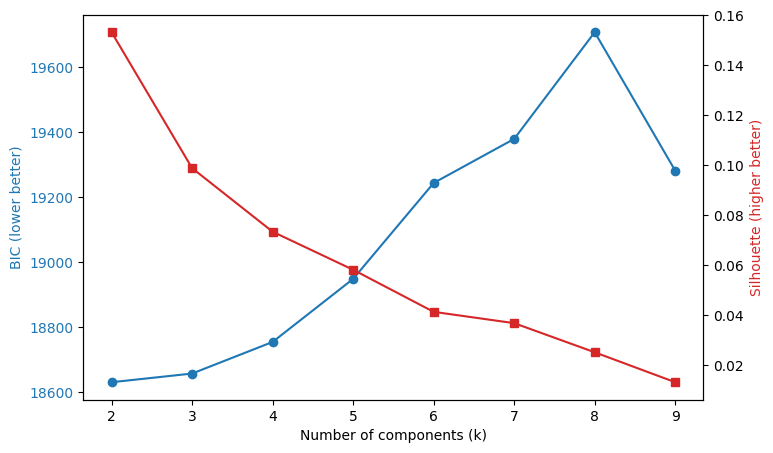

In [ ]:
# BLOCK 11: GMM model comparison

from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

K_RANGE = range(2, 10)
RANDOM_STATE = 42

results = []
for k in K_RANGE:
    # n_init=10 guards against a bad local optimum
    gmm = GaussianMixture(
        n_components=k,
        covariance_type='full',
        n_init=10,
        random_state=RANDOM_STATE,
    )
    gmm.fit(X_est_scaled)

    # hard labels for the silhouette score and the cluster size check
    labels = gmm.predict(X_est_scaled)

    # silhouette undefined if only one component is occupied
    n_occupied = len(np.unique(labels))
    sil = silhouette_score(X_est_scaled, labels) if n_occupied >= 2 else np.nan

    counts = np.bincount(labels, minlength=k)
    results.append({
        'k': k,
        'bic': gmm.bic(X_est_scaled),
        'silhouette': sil,
        'converged': gmm.converged_,
        'min_component': int(counts.min()),
        'n_occupied': n_occupied,
    })

results_df = pd.DataFrame(results)
print(results_df.round(3).to_string(index=False))

# plot BIC and silhouette together
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(results_df['k'], results_df['bic'], marker='o', color='tab:blue')
ax1.set_xlabel('Number of components (k)')
ax1.set_ylabel('BIC (lower better)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(results_df['k'], results_df['silhouette'], marker='s', color='tab:red')
ax2.set_ylabel('Silhouette (higher better)', color='tab:red')

### Model selection review

BIC is lowest at k=2 and rises across the candidate range; silhouette is highest at k=2 (0.153) and falls. Both prefer few components, and the best silhouette is weak in absolute terms, so the style space does not separate into clear clusters at any k. This is consistent with the soft assignment design: fighters sit on a continuum rather than in strict style kinds, which is why probabilistic membership was chosen over hard labels.

k cannot be selected on these scores; the preferred k=2 gives no usable style vocabulary. Selection moves to interpretability, with the scores as a guide: components stay populated through k=6 (smallest cluster 59) and thin out by k=7 to 8 (40, then 23), too small. The archetype check therefore runs on k=4, 5, 6.

## Section 6: Component archetype profiles

The model comparison narrowed the choice to k = 4, 5, and 6. This block fits the GMM at each, assigns every Established fighter to their most probable component, and describes each component by its mean across all eleven style features on the original, untransformed scale. Reading a component's column down all eleven features is what identifies the fighter type it represents.

clinch_share is included in the profile even though it was excluded from the model input, since it still carries interpretive value. The highest-confidence fighters from each component are listed as a validity check.

In [ ]:
# BLOCK 12: archetype profiles for k = 4, 5, 6
from sklearn.mixture import GaussianMixture

# model inputs plus clinch_share
profile_cols = [
    'sig_str_per_min', 'sig_str_accuracy', 'sig_str_absorbed_per_min',
    'td_attempts_per15', 'td_accuracy', 'sub_att_per15', 'ctrl_pct',
    'kd_per_fight', 'distance_share', 'clinch_share', 'ground_share',
]

# index aligns with X_est_scaled
temp_established = style[mask_est].copy()

CANDIDATE_K = [4, 5, 6]
N_EXAMPLES = 6
RANDOM_STATE = 42

profiles = {}   # per-k profile tables for later reference

for k in CANDIDATE_K:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type='full',
        n_init=10,
        random_state=RANDOM_STATE,
    )
    gmm.fit(X_est_scaled)
    labels = gmm.predict(X_est_scaled)
    conf = gmm.predict_proba(X_est_scaled).max(axis=1)

    # only k=4 is used downstream
    if k == 4:
        temp_established['component_k4'] = labels

    # profile on the original scale so the means read as fight statistics
    prof_input = temp_established[['FIGHTER'] + profile_cols].copy()
    prof_input['component'] = labels
    prof_input['confidence'] = conf

    prof = prof_input.groupby('component')[profile_cols].mean().round(2)
    prof.insert(0, 'n', prof_input['component'].value_counts().sort_index())
    profiles[k] = prof

    print(f'\nk = {k}')
    print(prof.to_string())
    for c in range(k):
        names = (prof_input[prof_input['component'] == c]
                 .nlargest(N_EXAMPLES, 'confidence')['FIGHTER'].tolist())
        print(f'  component {c}: {names}')

established = temp_established.copy()


k = 4
             n  sig_str_per_min  sig_str_accuracy  sig_str_absorbed_per_min  td_attempts_per15  td_accuracy  sub_att_per15  ctrl_pct  kd_per_fight  distance_share  clinch_share  ground_share
component                                                                                                                                                                                     
0          204             4.17              0.44                      4.64               2.41         0.26           0.06      0.10          0.18            0.85          0.11          0.04
1          264             3.18              0.44                      3.46               5.61         0.36           0.54      0.25          0.09            0.74          0.13          0.13
2          168             4.09              0.47                      4.03               1.96         0.41           0.34      0.11          0.38            0.83          0.07          0.10
3          135             3.05       

## Section 7: Era effects in the components

The style features (strike rate, takedown volume, strikes absorbed) have drifted across the modern era as the environment changed; two fighters from different periods with similar raw numbers are not necessarily similar in style relative to their contemporaries. The recency weighting addresses drift within a fighter's own record; it does nothing about the comparability of the feature scale across eras.

This block tags each Established fighter by the median year of their fights, buckets them into three periods, and cross-tabulates against the k=4 component, comparing each component's era mix against the overall era distribution.

Cramer's V summarises the strength of the component / era association on a 0 to 1 scale.

In [ ]:
# BLOCK 13: era check on the k=4 components

# reduce the modern era round data to one row per fight then tag the median
# last year of fights for fighters
fights = (
    df_rounds_modern[['FIGHTER', 'EVENT', 'BOUT', 'date']]
    .drop_duplicates(subset=['FIGHTER', 'EVENT', 'BOUT'])
    .copy()
)
fights['year'] = fights['date'].dt.year

fighter_era = fights.groupby('FIGHTER').agg(
    mid_year=('year', 'median'),
).reset_index()

# tag fighter to the era they were most active in (median fight year)
ERA_TAG_COL = 'mid_year'
era_bins = [1999, 2010, 2018, 2026]
era_labels = ['2000-2010', '2011-2018', '2019-2026']
fighter_era['era_band'] = pd.cut(fighter_era[ERA_TAG_COL], bins=era_bins, labels=era_labels)

# attach the era tag to the Established fighters carrying the k=4 labels
est_era = established.merge(
    fighter_era[['FIGHTER', 'era_band']], on='FIGHTER', how='left'
)

# report any fighter that failed to get an era tag
n_missing = int(est_era['era_band'].isna().sum())
print(f'Established fighters: {len(est_era):,}')
print(f'without an era band: {n_missing}\n')

# cross tab component against era
ct_counts = pd.crosstab(est_era['component_k4'], est_era['era_band'])
ct_rowpct = (pd.crosstab(est_era['component_k4'], est_era['era_band'],
                         normalize='index') * 100).round(1)

base_rate = (est_era['era_band'].value_counts(normalize=True)
             .reindex(era_labels) * 100).round(1)

print('component x era band (counts):')
print(ct_counts.to_string())
print("\ncomponent x era band (row %, each component's era mix):")
print(ct_rowpct.to_string())
print('\nbase rate (overall era distribution, %):')
print(base_rate.to_string())

# Cramer's V on the contingency table:
#   0 means component independent of era,
#   1 means era fully determines the component
chi2 = chi2_contingency(ct_counts)[0]
n = ct_counts.to_numpy().sum()
r, c = ct_counts.shape
cramers_v = np.sqrt((chi2 / n) / min(r - 1, c - 1))
print(f"\nCramer's V (component vs era): {cramers_v:.3f}")

Established fighters: 771
without an era band: 0

component x era band (counts):
era_band      2000-2010  2011-2018  2019-2026
component_k4                                 
0                    15         75        114
1                    27        119        118
2                     7         67         94
3                    47         54         34

component x era band (row %, each component's era mix):
era_band      2000-2010  2011-2018  2019-2026
component_k4                                 
0                   7.4       36.8       55.9
1                  10.2       45.1       44.7
2                   4.2       39.9       56.0
3                  34.8       40.0       25.2

base rate (overall era distribution, %):
era_band
2000-2010    12.5
2011-2018    40.9
2019-2026    46.7

Cramer's V (component vs era): 0.243


### Era check review

Cramer's V is 0.243, a weak association: era influences the clustering but is not a key driver. Three of the four components (0, 1, 2) track the overall era base rate closely.

Component 3, the submission-grappler profile, is the exception. The 2000-2010 band is nearly three times over-represented (34.8% against a 12.5% base) and the current era is under-represented (25.2% against 46.7%). Submission-based ground styles were more common in the mid-2000s, so a component defined on those features pulls in early-era fighters disproportionately. The component is a genuine style but is entangled with the period that style was most prevalent.

### Profile analysis

k = 4 gives the cleanest option: four nameable archetypes, no residual "average everything" bucket, and every component carries a distinct high or low. k = 5 splits a control-wrestler type out but introduces a large near-average component (n=257) with no clear identity; k = 6 keeps that residual and adds a thin component (n=59) without improving interpretability. **k = 4 is selected.**

The four components, across all eleven features on the original scale:
- Component 0 (n=204): distance striker. Low takedowns, low control, high distance share, moderate knockdowns.
- Component 1 (n=264): volume wrestler. Highest takedown attempts, moderate control, low knockdowns.
- Component 2 (n=168): knockout striker. High accuracy, highest knockdown rate, low takedowns; distinguished from the distance striker by finishing power.
- Component 3 (n=135): submission grappler. Highest submission attempts, highest control and ground share. Era-associated (see era check).

Selection was heavily determined by interpretability, not the model selection scores, which preferred k=2 and indicated weak overall separation. The components are a coordinate system over a continuous style space.

## Section 8: Seed stability of the k=4 component

The model selection scores showed weak separation, so the current splits could be real structure or an artefact of one random seed. This block tests that directly: it refits k=4 under a range of seeds and measures how much each partition agrees with the locked seed-42 reference. Adjusted Rand Index is the right measure because it is invariant to label permutation. High agreement means the archetypes are a real feature of the data; low agreement means they are an artefact of one fit.

In [ ]:
# BLOCK 14: seed stability check on the k=4 partition

K = 4
SEEDS = [42, 7, 13, 21, 99, 123, 2024, 555, 888, 1001]

# reference partition from the locked seed
ref_gmm = GaussianMixture(n_components=K, covariance_type='full',
                          n_init=10, random_state=SEEDS[0])
ref_labels = ref_gmm.fit_predict(X_est_scaled)

# refit under each alternative seed and compare to the reference
# ARI = 1.0 identical, 0.0 chance agreement
ari_scores = []
for seed in SEEDS[1:]:
    gmm = GaussianMixture(n_components=K, covariance_type='full',
                          n_init=10, random_state=seed)
    labels = gmm.fit_predict(X_est_scaled)
    ari = adjusted_rand_score(ref_labels, labels)
    ari_scores.append(ari)
    print(f'seed {seed:>5}: ARI vs reference = {ari:.3f}')

ari_arr = np.array(ari_scores)
print(f'\nARI across {len(SEEDS)-1} alternative seeds:')
print(f'  mean {ari_arr.mean():.3f}   min {ari_arr.min():.3f}   max {ari_arr.max():.3f}')

seed     7: ARI vs reference = 0.997
seed    13: ARI vs reference = 0.986
seed    21: ARI vs reference = 0.997
seed    99: ARI vs reference = 0.997
seed   123: ARI vs reference = 0.997
seed  2024: ARI vs reference = 0.986
seed   555: ARI vs reference = 0.997
seed   888: ARI vs reference = 0.997
seed  1001: ARI vs reference = 0.997

ARI across 9 alternative seeds:
  mean 0.994   min 0.986   max 0.997


### Stability check analysis

Mean ARI is 0.994 across nine alternative seeds (min 0.986, max 0.997): the k=4 partition is essentially constant. Every seed recovers the same four groups, with only a few edge fighters mixing between fits.

In conjunction with the weak silhouette (0.073 at k=4), this is an accurate description of the structure. Silhouette measures separation and found no clear gaps between the styles; stability measures reproducibility and found the model draws the same boundaries every time. The style space is therefore continuous but partitioned consistently. The archetypes are stable enough to use, and the absence of separation is why grouping is measured as a probability vector instead of a hard label.

## Section 9: Final fit and cluster labels

k=4 confirmed. This block fits the final GMM on the Established set with the locked config and produces soft memberships for all relevant fighters. The fit set stays Established only (8+ fights) for stable component estimates, while a probability is predicted across the four archetypes for every fighter down to the 2-fight floor; the dashboard and the public profile axis need a style read on the full fighter set, not just the established names. STYLE_TIER moves with the output so downstream work can weight a 2-fight fighter's placement as less reliable than an established one. Output saves to `style_clusters.parquet`, the deliverable the public profile notebook consumes.

In [ ]:
# BLOCK 15: final k=4 fit and apply soft cluster labels

K = 4
RANDOM_STATE = 42

final_gmm = GaussianMixture(n_components=K, covariance_type='full',
                            n_init=10, random_state=RANDOM_STATE)
final_gmm.fit(X_est_scaled)

ARCHETYPE_NAMES = {
    0: 'Distance striker',
    1: 'Volume wrestler',
    2: 'Knockout striker',
    3: 'Submission grappler',
}

# the final fit must reproduce earlier values
assert np.array_equal(
    final_gmm.predict(X_est_scaled), established['component_k4'].values
), 'final fit differs from the archetype-profile fit; archetype name map no longer valid'
print('component identity confirmed against the archetype-profile fit')

# soft memberships for the full 2+ population; predict_proba gives the probability per archetype
proba_all = final_gmm.predict_proba(X_all_scaled)

clusters = style[['FIGHTER', 'n_fights', 'STYLE_TIER']].copy()

# one probability column per archetype
for idx, name in ARCHETYPE_NAMES.items():
    clusters[f'p_{name.lower().replace(" ", "_")}'] = proba_all[:, idx]

# hard primary style (most probable archetype) and its probability, for filtering and display
hard_idx = proba_all.argmax(axis=1)
clusters['primary_style'] = [ARCHETYPE_NAMES[i] for i in hard_idx]
clusters['style_confidence'] = proba_all.max(axis=1)

# the four probabilities should sum to 1 per fighter
prob_cols = [f'p_{n.lower().replace(" ", "_")}' for n in ARCHETYPE_NAMES.values()]
assert np.allclose(clusters[prob_cols].sum(axis=1), 1.0), 'memberships do not sum to 1'

print(f'\nlabelled {len(clusters):,} fighters across {K} archetypes')
print('\nprimary style distribution:')
print(clusters['primary_style'].value_counts().to_string())
print('\nmean confidence by primary style:')
print(clusters.groupby('primary_style')['style_confidence'].mean().round(3).to_string())
print('\nmean confidence by reliability tier:')
print(clusters.groupby('STYLE_TIER')['style_confidence'].mean().round(3).to_string())

clusters.to_parquet(OUTPUT_DIR / 'style_clusters.parquet', index=False)
print('style_clusters.parquet saved')

component identity confirmed against the archetype-profile fit

labelled 2,196 fighters across 4 archetypes

primary style distribution:
primary_style
Submission grappler    638
Volume wrestler        629
Distance striker       579
Knockout striker       350

mean confidence by primary style:
primary_style
Distance striker       0.911
Knockout striker       0.881
Submission grappler    0.935
Volume wrestler        0.872

mean confidence by reliability tier:
STYLE_TIER
Established    0.900
Provisional    0.889
Unreliable     0.917
style_clusters.parquet saved


### Understanding the final labels

The four archetypes split the fighters at 638 / 629 / 579 / 350 (submission grappler, volume wrestler, distance striker, knockout striker). No trivial solutions and no single type dominating; knockout striker being smallest is consistent with pure finishers being rarer than wrestlers or volume strikers.

Mean confidence is high across all four styles (0.87 to 0.94). Despite the weak silhouette, most fighters are placed fairly decisively in one archetype, with a minority genuinely mixed. The "soft" in soft assignment is real but applies to a minority.

Confidence by reliability tier is not as initially expected: Unreliable (2 to 3 fights) is highest at 0.917, Established at 0.900. This is due to limited data, not a sign that this group is better characterised. A two-fight profile is usually at the extreme of one or two features and sits confidently inside a single component, so style_confidence should not be confused for reliability.

STYLE_TIER is carried so downstream use (dashboard, public-profile axis) displays confidence and tier together and flags those with a small evidence base, rather than treating them as equally trustworthy.

The style features describe where a fighter spends time and at what rate; none describes what ends the fight. A fighter who finishes opponents with strikes on the mat and a fighter who submits them both register a high ground share, for opposite reasons, and the feature set cannot separate them.

The clearest case in the population is the promotion's knockout record holder, who has never attempted a submission and is nonetheless assigned to the submission-grappler component with near total confidence. The assignment does not reflect a poor fit: his log-likelihood under the mixture sits near the middle of the scored population, so the model represents him about as well as it represents anyone, and it is reading the features correctly. Three of the five discriminating inputs point at the grappler component, being low striking volume, low distance share and high ground share; the two that point away, a knockdown rate above every component mean and no submission attempts, are outvoted.

The consequence is bounded. The style layer is interpretive and weights neither axis, so a wrong descriptor surfaces as a dashboard label rather than as a misplaced fighter. A finish-mechanism feature would address it and is recorded as future work.